In [ ]:
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.0 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.16.0
    Uninstalling openai-2.16.0:
      Successfully uninstalled openai-2.16.0


In [ ]:
import openai
import matplotlib.pyplot as plt
import numpy as np

# Initialize OpenAI client
client = openai.OpenAI(api_key="Your API Key")

# The incomplete sentence
sentence = "After years of hard work, your effor will take you"

# Get completion with logprobs
response = client.completions.create(
    model="gpt-3.5-turbo-instruct",
    prompt=sentence,
    max_tokens=1,
    logprobs=50, # request 50 logprobs
    temperature=0,
)

# Extract and convert logprobs to probabilities
logprobs_data = response.choices[0].logprobs.top_logprobs[0] # Access the dictionary of token logprobs
print(f"Number of tokens received: {len(response.choices[0].logprobs.tokens)}")

probs = {token: np.exp(logprob) for token, logprob in logprobs_data.items()}

# Normalize probabilities
total = sum(probs.values())
probs = {token: prob / total for token, prob in probs.items()}

# Sort tokens by probability
sorted_tokens = sorted(probs.items(), key=lambda x: x[1], reverse=True)
print("\nTop 10 tokens with their probabilities:")
for token, prob in sorted_tokens[:10]:
    print(f"'{token}': {prob:.3f}")

tokens, probabilities = zip(*sorted_tokens)

# Create visualization showing all available tokens
plt.figure(figsize=(15, 10))
plt.barh(range(len(tokens)), probabilities)
plt.yticks(range(len(tokens)), tokens)
plt.ylabel("Token")
plt.xlabel("Probability")
plt.title(f"Distribution of next token Probability (Total tokens: {len(tokens)})")

# Add percentage labels for top probabilities only (to avoid cluttering)
for i, prob in enumerate(probabilities[:10]):
    plt.text(prob, i, f"{prob*100:.1f}%", ha='left', va='center')

plt.gca().invert_yaxis() # Invert y-axis to have the highest probability at the top
plt.tight_layout()
plt.show()

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: Your API Key. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

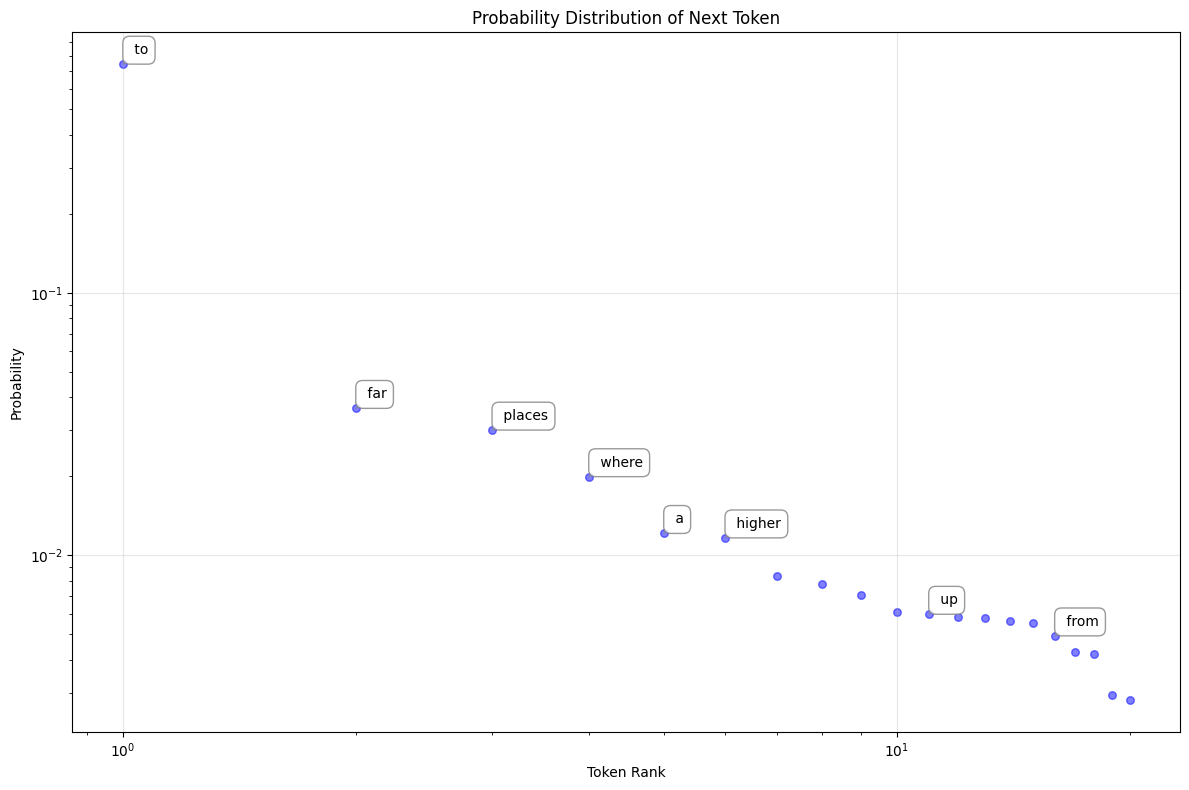

In [ ]:
import openai
import matplotlib.pyplot as plt, numpy as np
# Initialize OpenAI client
client = openai.OpenAI (api_key="Your API Key")
#The incomplete sentence
sentence = "After years of hard work, your effort will take you"
# Get completion with logprobs
response = client.completions.create(
model="gpt-3.5-turbo-instruct", prompt=sentence,
max_tokens=1,
logprobs=50,
temperature=0
)
#Extract and convert logprobs to probabilities
logprobs = response.choices [0].logprobs.top_logprobs [0]
probs = {token: np.exp(logprob) for token, logprob in logprobs.items()}


# Sort probabilities
sorted_items = sorted (probs.items(), key=lambda x: x[1], reverse=True)
tokens, probabilities = zip(*sorted_items)
# Create the plot
plt.figure(figsize=(12, 8))
# Create scatter plot with logarithmic axes
x_positions = np.arange(1, len(tokens) + 1)
plt.scatter(x_positions, probabilities, color='blue', alpha=0.5, s=30)

# Set logarithmic scale for both axes
plt.xscale('log')
plt.yscale('log')

# Customize the plot
plt.grid(True, alpha=0.3)
plt.xlabel('Token Rank')
plt.ylabel('Probability')
plt.title('Probability Distribution of Next Token')

# Add token labels with lines
for i, (token, prob) in enumerate (zip (tokens, probabilities)):
    # Add labels for selected tokens
    if prob > 0.01 or i % 5 == 0:
        plt.annotate(
            token,
            xy=(x_positions[i], prob), xytext=(5, 5),
            textcoords='offset points',
            ha='left',
            va='bottom',
            bbox=dict (boxstyle='round, pad=0.5', fc='white', ec='gray', alpha=0.8),
            arrowprops=dict (arrowstyle= '-', color='gray', alpha=0.5)
        )
# Adjust layout
plt.tight_layout()
plt.show()